# 🍈 Clustering Wilayah Rawan Bencana Indonesia

**Dataset:** BNPB Records (2018-2024)  
**Metode:** K-Means Clustering  
**Author:** Guava

---

## 📋 Tujuan Project

Mengelompokkan provinsi di Indonesia berdasarkan pola bencana alam untuk:
1. Identifikasi zona risiko bencana
2. Rekomendasi alokasi resources BNPB
3. Prioritas mitigasi per wilayah

## 1️⃣ Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded")

✅ Libraries loaded


## 2️⃣ Load Data

In [28]:
# Load dataset
df = pd.read_excel('data_bencana.xlsx')

print(f"📊 Data shape: {df.shape}")
print(f"\n📋 Columns: {df.columns.tolist()}")

# Display sample
df.head()

📊 Data shape: (28773, 12)

📋 Columns: ['city_id', 'date', 'disaster_type', 'city', 'province', 'cause', 'death', 'missing_person', 'injured_person', 'damaged_house', 'flooded_house', 'damaged_facility']


,city_id,date,disaster_type,city,province,cause,death,missing_person,injured_person,damaged_house,flooded_house,damaged_facility
0,5310,2018-01-01,BANJIR,MANGGARAI,NUSA TENGGARA TIMUR,Tidak diketahui,0.0,0.0,0.0,1.0,0.0,0
1,6311,2018-01-01,BANJIR,BALANGAN,KALIMANTAN SELATAN,Tidak diketahui,0.0,0.0,0.0,0.0,25.0,0
2,5103,2018-01-01,BANJIR,BADUNG,BALI,Tidak diketahui,0.0,0.0,0.0,0.0,3.0,0
3,5106,2018-01-01,TANAH LONGSOR,BANGLI,BALI,Tidak diketahui,0.0,0.0,0.0,1.0,0.0,0
4,5310,2018-01-01,TANAH LONGSOR,MANGGARAI,NUSA TENGGARA TIMUR,Tidak diketahui,0.0,0.0,0.0,1.0,0.0,0


In [29]:
# Info dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28773 entries, 0 to 28772
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   city_id           28773 non-null  int64         
 1   date              28773 non-null  datetime64[us]
 2   disaster_type     28773 non-null  str           
 3   city              28773 non-null  str           
 4   province          28773 non-null  str           
 5   cause             28773 non-null  str           
 6   death             28772 non-null  float64       
 7   missing_person    27659 non-null  float64       
 8   injured_person    28773 non-null  float64       
 9   damaged_house     28773 non-null  float64       
 10  flooded_house     27659 non-null  float64       
 11  damaged_facility  28773 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(2), str(4)
memory usage: 2.6 MB


In [30]:
# Statistik deskriptif
df.describe()

,city_id,date,death,missing_person,injured_person,damaged_house,flooded_house,damaged_facility
count,28773.000000,28773,28772.000000,27659.000000,28773.000000,28773.000000,27659.000000,28773.000000
mean,3827.540159,2021-04-04 00:14:30.816390,0.423768,0.048769,2.639878,29.499714,228.943618,1.071630
min,1101.000000,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3201.000000,2019-12-13 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3310.000000,2021-03-27 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5271.000000,2022-10-15 00:00:00,0.222073,0.001296,0.424833,2.000000,7.000000,0.000000
max,9671.000000,2024-05-21 00:00:00,3624.000000,570.000000,11124.000000,72194.000000,104114.000000,2037.000000
std,1946.759128,NaN,22.060696,3.543172,100.503852,787.316100,1665.885047,22.136537


## 3️⃣ Data Preprocessing

In [31]:
# Check missing values
print("❓ Missing Values:")
print(df.isnull().sum())

❓ Missing Values:
city_id                0
date                   0
disaster_type          0
city                   0
province               0
cause                  0
death                  1
missing_person      1114
injured_person         0
damaged_house          0
flooded_house       1114
damaged_facility       0
dtype: int64


In [32]:
# Handle missing values
df.dropna(subset=['death'], inplace=True)
for col in ['missing_person', 'injured_person', 'flooded_house', 'damaged_house', 'damaged_facility']:
    df[col] = df[col].fillna(0)

# Normalisasi nama provinsi duplikat (varian ejaan/spasi) sebelum agregasi,
# agar kejadian satu provinsi tidak terpecah jadi dua baris.
# Provinsi baru hasil pemekaran 2022 (PAPUA BARAT DAYA/PEGUNUNGAN/SELATAN/TENGAH) tetap terpisah.
province_name_fix = {
    'P A P U A': 'PAPUA',
    'DAERAH ISTIMEWA YOGYAKARTA': 'DI YOGYAKARTA',
}
df['province'] = df['province'].replace(province_name_fix)

print(f"✅ Data after cleaning: {len(df)} rows")
print(f"✅ Missing values handled")
print(f"✅ Province names normalized: {df['province'].nunique()} unique provinces")

✅ Data after cleaning: 28772 rows
✅ Missing values handled
✅ Province names normalized: 38 unique provinces


In [33]:
# Extract date features
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print("✅ Date features extracted")
print(f"\n📅 Periode data: {df['date'].min()} s/d {df['date'].max()}")

✅ Date features extracted

📅 Periode data: 2018-01-01 00:00:00 s/d 2024-05-21 00:00:00


## 4️⃣ Exploratory Data Analysis (EDA)

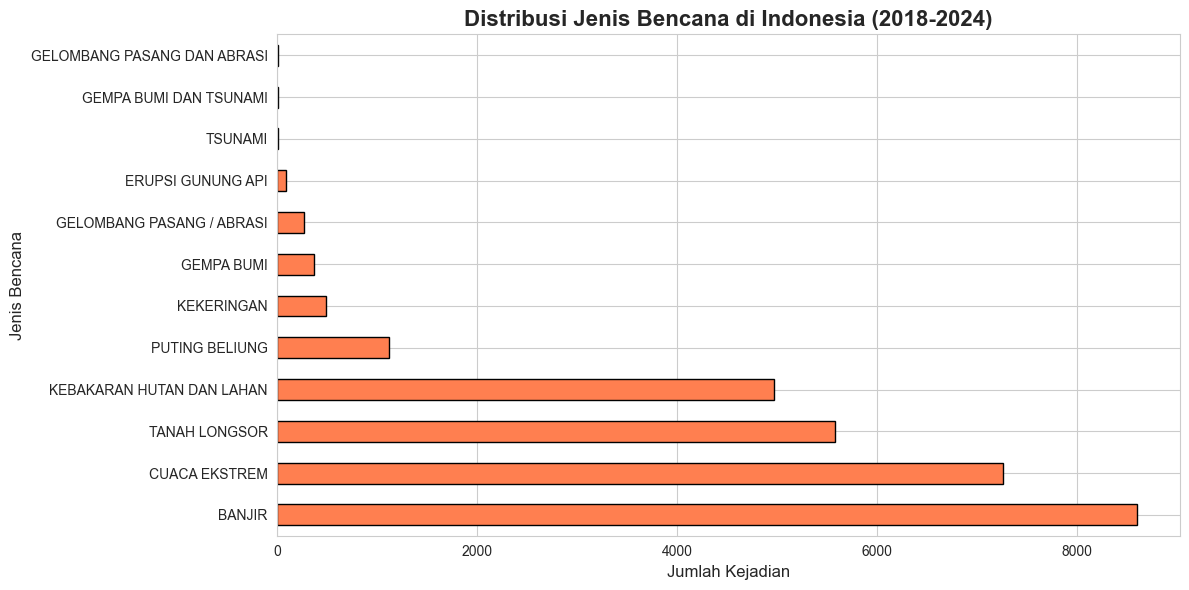

disaster_type
BANJIR                         8605
CUACA EKSTREM                  7268
TANAH LONGSOR                  5585
KEBAKARAN HUTAN DAN LAHAN      4967
PUTING BELIUNG                 1113
KEKERINGAN                      489
GEMPA BUMI                      370
GELOMBANG PASANG / ABRASI       270
ERUPSI GUNUNG API                90
TSUNAMI                           7
GEMPA BUMI DAN TSUNAMI            5
GELOMBANG PASANG DAN ABRASI       3
Name: count, dtype: int64


In [34]:
# Top 10 jenis bencana
plt.figure(figsize=(12, 6))
disaster_counts = df['disaster_type'].value_counts()
disaster_counts.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Distribusi Jenis Bencana di Indonesia (2018-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Kejadian', fontsize=12)
plt.ylabel('Jenis Bencana', fontsize=12)
plt.tight_layout()
plt.show()

print(disaster_counts)

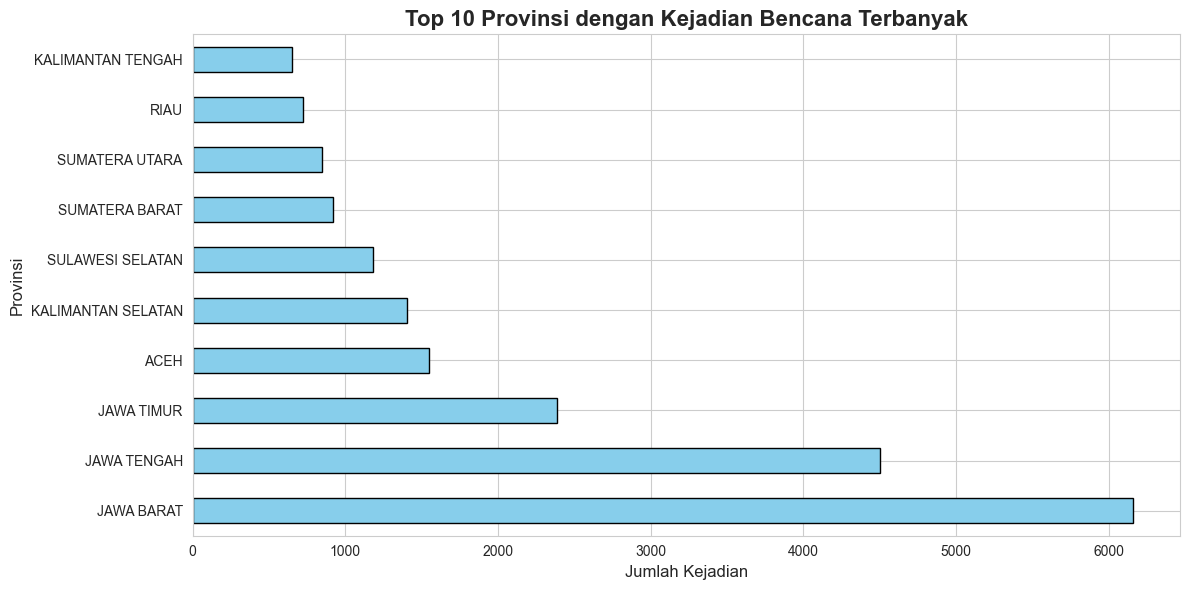

province
JAWA BARAT            6159
JAWA TENGAH           4500
JAWA TIMUR            2387
ACEH                  1548
KALIMANTAN SELATAN    1403
SULAWESI SELATAN      1182
SUMATERA BARAT         921
SUMATERA UTARA         848
RIAU                   721
KALIMANTAN TENGAH      653
Name: count, dtype: int64


In [35]:
# Top 10 provinsi paling rawan
plt.figure(figsize=(12, 6))
province_counts = df['province'].value_counts().head(10)
province_counts.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top 10 Provinsi dengan Kejadian Bencana Terbanyak', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Kejadian', fontsize=12)
plt.ylabel('Provinsi', fontsize=12)
plt.tight_layout()
plt.show()

print(province_counts)

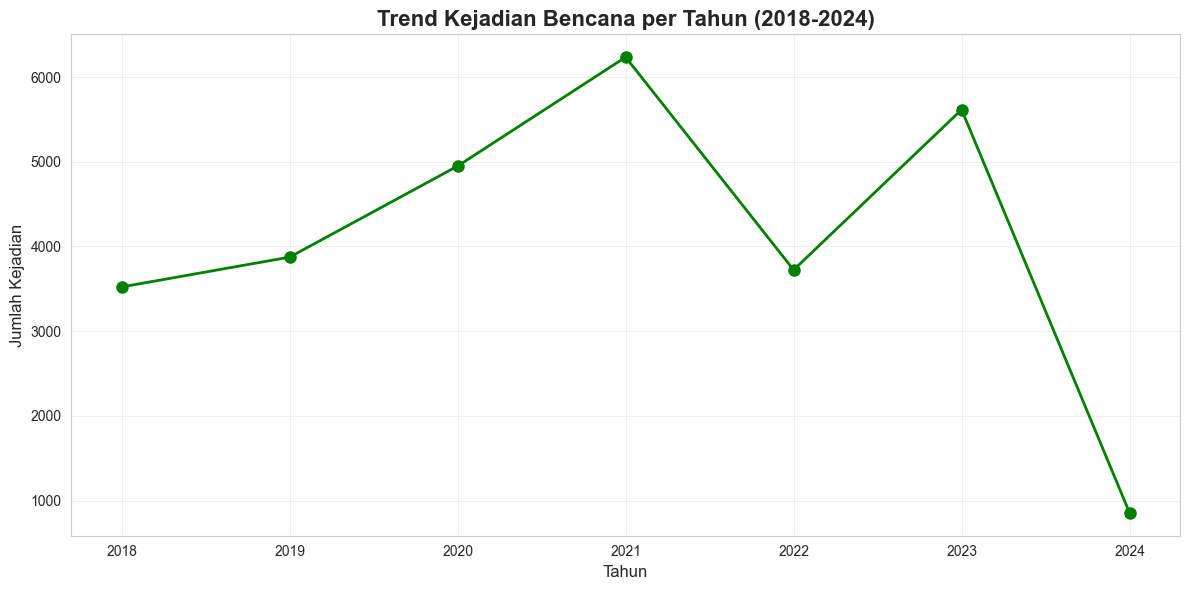

In [36]:
# Trend bencana per tahun
plt.figure(figsize=(12, 6))
year_counts = df['year'].value_counts().sort_index()
year_counts.plot(kind='line', marker='o', color='green', linewidth=2, markersize=8)
plt.title('Trend Kejadian Bencana per Tahun (2018-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Kejadian', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5️⃣ Feature Engineering

In [37]:
# Agregasi per provinsi
province_agg = df.groupby('province').agg({
    'city_id': 'count',
    'death': 'sum',
    'injured_person': 'sum',
    'missing_person': 'sum',
    'damaged_house': 'sum',
    'flooded_house': 'sum',
    'damaged_facility': 'sum'
}).reset_index()

province_agg.columns = ['province', 'total_disasters', 'total_death', 'total_injured', 
                        'total_missing', 'total_damaged_house', 'total_flooded_house', 
                        'total_damaged_facility']

print(f"✅ Agregasi provinsi: {len(province_agg)} rows")
province_agg.head()

✅ Agregasi provinsi: 38 rows


,province,total_disasters,total_death,total_injured,total_missing,total_damaged_house,total_flooded_house,total_damaged_facility
0,ACEH,1548,182.925760,641.829664,27.425990,5939.0,353395.937111,525
1,BALI,513,152.183311,1100.313696,3.168309,2897.0,11128.686583,1296
2,BANTEN,544,464.210834,10966.169797,19.408682,16739.0,110852.833692,521
3,BENGKULU,208,80.114522,228.550318,7.547596,3191.0,51343.115941,275
4,DI YOGYAKARTA,461,90.865216,397.162923,4.318454,3096.0,4744.898184,667


In [38]:
# Pivot jenis bencana per provinsi
disaster_pivot = df.pivot_table(
    index='province', 
    columns='disaster_type', 
    values='city_id', 
    aggfunc='count', 
    fill_value=0
).reset_index()

print(f"✅ Disaster pivot: {disaster_pivot.shape}")
disaster_pivot.head()

✅ Disaster pivot: (38, 13)


disaster_type,province,BANJIR,CUACA EKSTREM,ERUPSI GUNUNG API,GELOMBANG PASANG / ABRASI,GELOMBANG PASANG DAN ABRASI,GEMPA BUMI,GEMPA BUMI DAN TSUNAMI,KEBAKARAN HUTAN DAN LAHAN,KEKERINGAN,PUTING BELIUNG,TANAH LONGSOR,TSUNAMI
0,ACEH,566,365,0,18,0,5,0,478,2,53,61,0
1,BALI,69,116,27,13,0,35,0,33,13,6,201,0
2,BANTEN,244,156,0,0,0,14,0,44,16,24,44,2
3,BENGKULU,122,29,0,2,0,3,0,16,2,6,28,0
4,DI YOGYAKARTA,35,193,9,7,0,9,0,114,6,18,70,0


In [39]:
# Merge untuk feature matrix lengkap
province_features = province_agg.merge(disaster_pivot, on='province')

print(f"✅ Feature matrix: {province_features.shape}")
print(f"   {len(province_features)} provinsi × {len(province_features.columns)-1} features")

# Save
province_features.to_csv('clustering_province_features.csv', index=False)
print("💾 Saved: clustering_province_features.csv")

province_features.head()

✅ Feature matrix: (38, 20)
   38 provinsi × 19 features
💾 Saved: clustering_province_features.csv


,province,total_disasters,total_death,total_injured,total_missing,total_damaged_house,total_flooded_house,total_damaged_facility,BANJIR,CUACA EKSTREM,ERUPSI GUNUNG API,GELOMBANG PASANG / ABRASI,GELOMBANG PASANG DAN ABRASI,GEMPA BUMI,GEMPA BUMI DAN TSUNAMI,KEBAKARAN HUTAN DAN LAHAN,KEKERINGAN,PUTING BELIUNG,TANAH LONGSOR,TSUNAMI
0,ACEH,1548,182.925760,641.829664,27.425990,5939.0,353395.937111,525,566,365,0,18,0,5,0,478,2,53,61,0
1,BALI,513,152.183311,1100.313696,3.168309,2897.0,11128.686583,1296,69,116,27,13,0,35,0,33,13,6,201,0
2,BANTEN,544,464.210834,10966.169797,19.408682,16739.0,110852.833692,521,244,156,0,0,0,14,0,44,16,24,44,2
3,BENGKULU,208,80.114522,228.550318,7.547596,3191.0,51343.115941,275,122,29,0,2,0,3,0,16,2,6,28,0
4,DI YOGYAKARTA,461,90.865216,397.162923,4.318454,3096.0,4744.898184,667,35,193,9,7,0,9,0,114,6,18,70,0


## 6️⃣ Data Standardization

In [40]:
# Prepare features untuk clustering
features_to_cluster = province_features.drop('province', axis=1)

# log1p meredam ekor kanan ekstrem -> satu kejadian katastropik 2018
# (Palu, Lombok, Selat Sunda) tidak lagi mendominasi jarak antar provinsi.
# Semua fitur adalah count non-negatif, jadi log1p aman (log1p(0)=0).
features_log = np.log1p(features_to_cluster)

# RobustScaler memakai median & IQR -> tahan terhadap sisa outlier
scaler = RobustScaler()
features_scaled = scaler.fit_transform(features_log)

print(f"✅ Features log-transformed & robust-scaled: {features_scaled.shape}")

✅ Features log-transformed & robust-scaled: (38, 19)


## 7️⃣ Elbow Method & Silhouette Score

In [41]:
# Calculate inertia & silhouette scores
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, kmeans.labels_))

print("✅ Elbow method calculated")

✅ Elbow method calculated


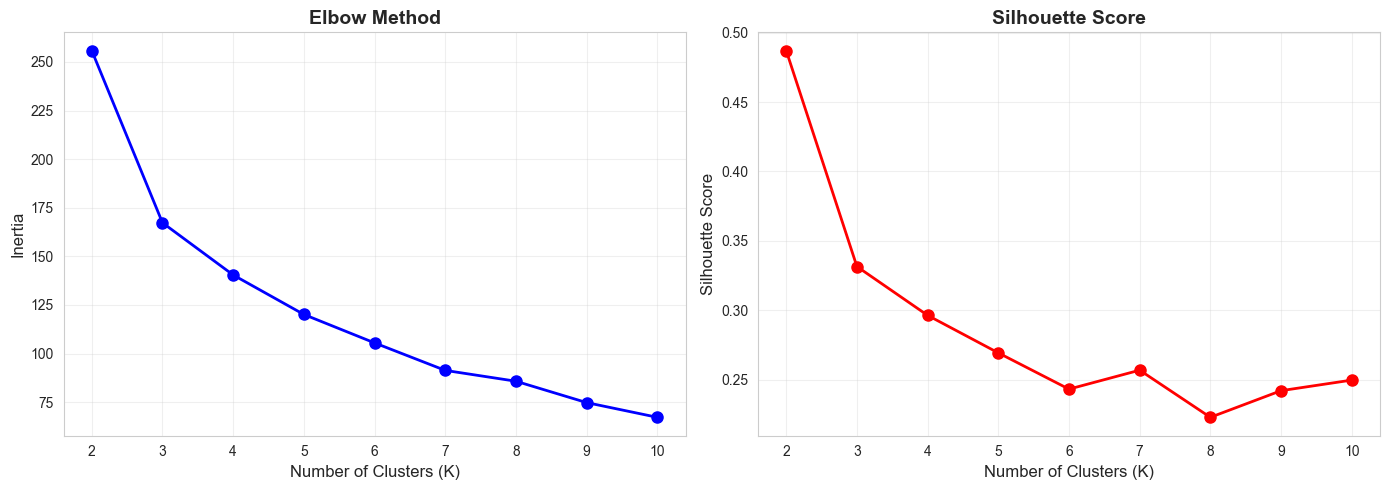

💾 Saved: elbow_method.png


In [42]:
# Plot Elbow & Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: elbow_method.png")

In [43]:
# Print scores
print("📈 Silhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"  K={k}: {score:.4f}")

silhouette_best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n📐 Silhouette tertinggi di K={silhouette_best_k} (Score: {max(silhouette_scores):.4f})")

# Override manual: pakai K=3 demi tingkatan risiko Low/High/Extreme.
# Silhouette memuncak di K=2 karena 5 provinsi pemekaran Papua 2022 (data ~1,5 thn)
# mendominasi sebagai outlier data-miskin sehingga memecah jadi 2 grup saja.
optimal_k = 3
print(f"🎯 K yang dipakai (manual): {optimal_k}")

📈 Silhouette Scores:
  K=2: 0.4871
  K=3: 0.3315
  K=4: 0.2963
  K=5: 0.2692
  K=6: 0.2431
  K=7: 0.2568
  K=8: 0.2228
  K=9: 0.2420
  K=10: 0.2496

📐 Silhouette tertinggi di K=2 (Score: 0.4871)
🎯 K yang dipakai (manual): 3


## 8️⃣ K-Means Clustering

In [44]:
# Clustering dengan K optimal
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
province_features['cluster'] = kmeans.fit_predict(features_scaled)

print(f"✅ Clustering completed with K={optimal_k}")
print(f"\n📊 Cluster distribution:")
print(province_features['cluster'].value_counts().sort_index())

✅ Clustering completed with K=3

📊 Cluster distribution:
cluster
0    21
1     4
2    13
Name: count, dtype: int64


## 9️⃣ Relabel Cluster (0=Low, 1=High, 2=Extreme)

In [45]:
# Calculate severity score per cluster
cluster_severity = province_features.groupby('cluster').agg({
    'total_disasters': 'mean',
    'total_death': 'mean',
    'total_injured': 'mean',
    'total_damaged_house': 'mean'
})

# Normalize and compute composite score
norm_scaler = MinMaxScaler()
normalized = norm_scaler.fit_transform(cluster_severity)
cluster_severity['composite_score'] = normalized.mean(axis=1)

print("📈 Severity scores:")
print(cluster_severity[['composite_score']].sort_values('composite_score'))

📈 Severity scores:
         composite_score
cluster                 
1               0.000000
0               0.166097
2               1.000000


In [46]:
# Map old to new cluster
severity_rank = cluster_severity['composite_score'].rank().astype(int) - 1
old_to_new = severity_rank.to_dict()

print("🔄 Cluster mapping:")
for old, new in old_to_new.items():
    print(f"  Cluster {old} (old) → Cluster {new} (new)")

# Apply relabeling
province_features['cluster'] = province_features['cluster'].map(old_to_new)

# Nama tier risiko (terendah -> tertinggi), beradaptasi terhadap optimal_k
if optimal_k == 2:
    cluster_labels = ['Low', 'High']
elif optimal_k == 3:
    cluster_labels = ['Low', 'High', 'Extreme']
else:
    cluster_labels = [f'Tier {i}' for i in range(optimal_k)]

print(f"\n✅ Clusters relabeled: {', '.join(f'{i}={n}' for i, n in enumerate(cluster_labels))}")

🔄 Cluster mapping:
  Cluster 0 (old) → Cluster 1 (new)
  Cluster 1 (old) → Cluster 0 (new)
  Cluster 2 (old) → Cluster 2 (new)

✅ Clusters relabeled: 0=Low, 1=High, 2=Extreme


## 🔟 Cluster Analysis

In [47]:
# Detailed analysis per cluster
for cluster_id in range(optimal_k):
    cluster_data = province_features[province_features['cluster'] == cluster_id]
    
    print("="*70)
    print(f"CLUSTER {cluster_id} - {len(cluster_data)} provinsi")
    print("="*70)
    
    print(f"\n📍 Provinsi:")
    for prov in cluster_data['province'].tolist():
        print(f"  - {prov}")
    
    print(f"\n📊 Rata-rata Metrics:")
    print(f"  Total Bencana: {cluster_data['total_disasters'].mean():.2f}")
    print(f"  Korban Meninggal: {cluster_data['total_death'].mean():.2f}")
    print(f"  Korban Luka: {cluster_data['total_injured'].mean():.2f}")
    print(f"  Rumah Rusak: {cluster_data['total_damaged_house'].mean():.2f}")
    print("\n")

CLUSTER 0 - 4 provinsi

📍 Provinsi:
  - PAPUA BARAT DAYA
  - PAPUA PEGUNUNGAN
  - PAPUA SELATAN
  - PAPUA TENGAH

📊 Rata-rata Metrics:
  Total Bencana: 4.50
  Korban Meninggal: 4.52
  Korban Luka: 10.52
  Rumah Rusak: 509.50


CLUSTER 1 - 21 provinsi

📍 Provinsi:
  - BENGKULU
  - DI YOGYAKARTA
  - DKI JAKARTA
  - GORONTALO
  - JAMBI
  - KALIMANTAN BARAT
  - KALIMANTAN TENGAH
  - KALIMANTAN TIMUR
  - KALIMANTAN UTARA
  - KEPULAUAN BANGKA BELITUNG
  - KEPULAUAN RIAU
  - LAMPUNG
  - MALUKU
  - MALUKU UTARA
  - PAPUA
  - PAPUA BARAT
  - RIAU
  - SULAWESI BARAT
  - SULAWESI TENGGARA
  - SULAWESI UTARA
  - SUMATERA SELATAN

📊 Rata-rata Metrics:
  Total Bencana: 338.67
  Korban Meninggal: 80.72
  Korban Luka: 1118.35
  Rumah Rusak: 5648.33


CLUSTER 2 - 13 provinsi

📍 Provinsi:
  - ACEH
  - BALI
  - BANTEN
  - JAWA BARAT
  - JAWA TENGAH
  - JAWA TIMUR
  - KALIMANTAN SELATAN
  - NUSA TENGGARA BARAT
  - NUSA TENGGARA TIMUR
  - SULAWESI SELATAN
  - SULAWESI TENGAH
  - SUMATERA BARAT
  - SUMATERA

In [48]:
# Save results
province_features.to_csv('clustering_results.csv', index=False)
print("💾 Saved: clustering_results.csv")

💾 Saved: clustering_results.csv


## 1️⃣1️⃣ PCA Visualization

In [49]:
# PCA for 2D visualization
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

province_features['PCA1'] = features_pca[:, 0]
province_features['PCA2'] = features_pca[:, 1]

print(f"📈 Explained Variance:")
print(f"  PCA1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PCA2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

📈 Explained Variance:
  PCA1: 70.06%
  PCA2: 8.45%
  Total: 78.51%


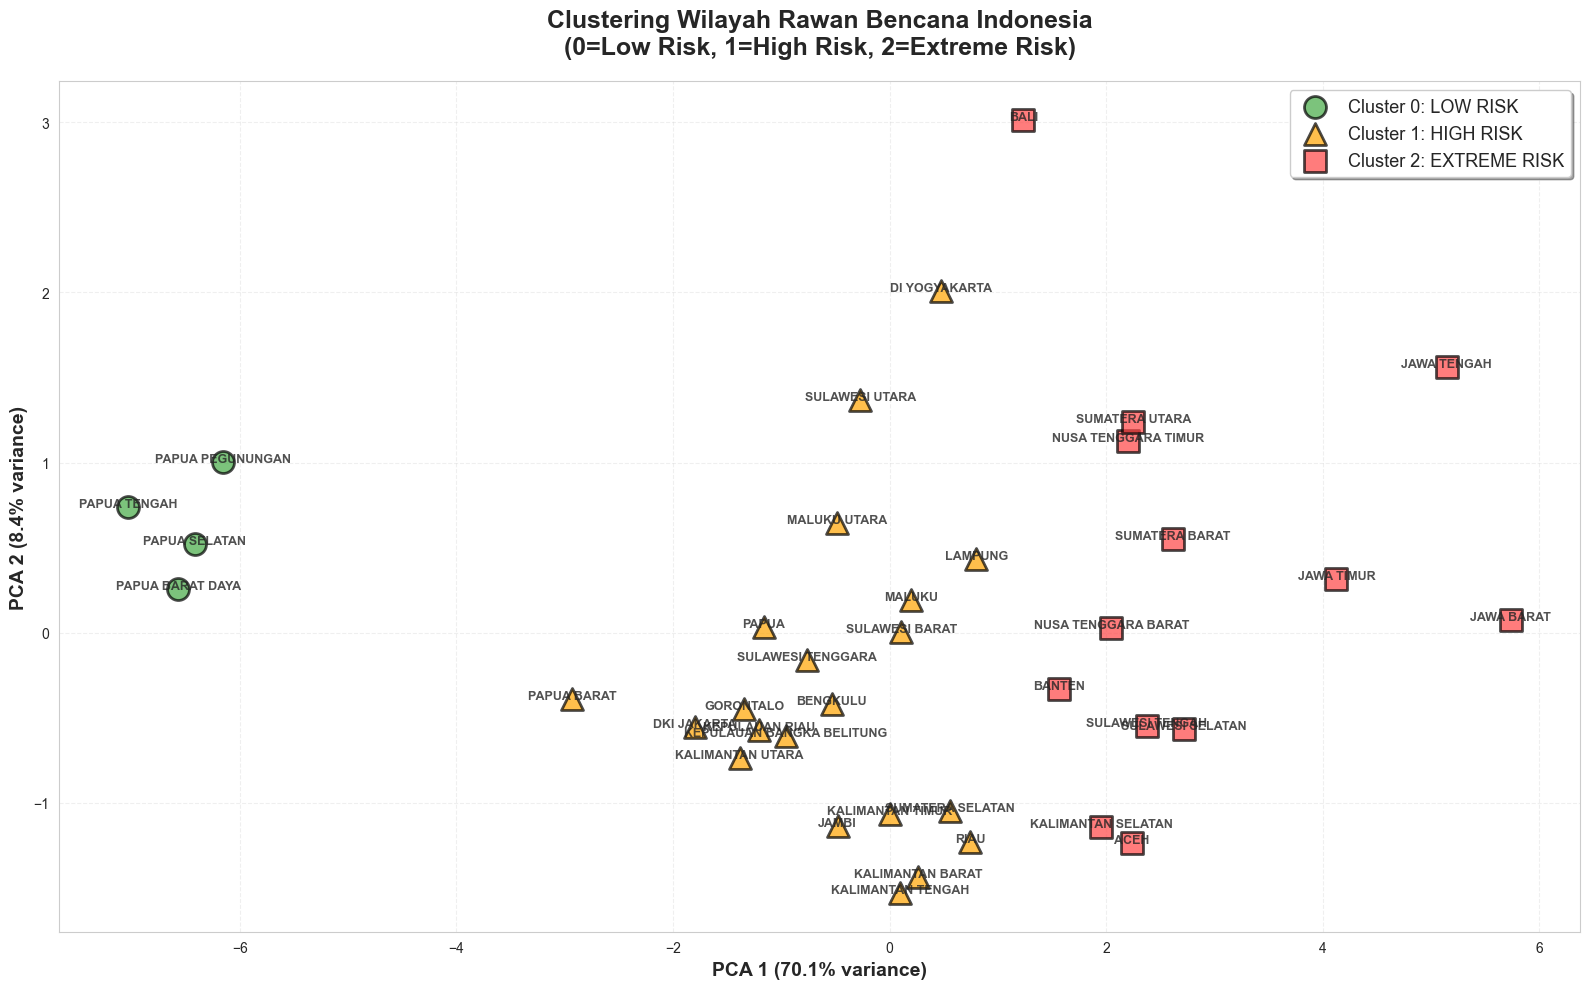

💾 Saved: clustering_visualization.png


In [50]:
# Plot PCA scatter
plt.figure(figsize=(16, 10))

_all_colors  = ['#44AA44', '#FFA500', '#FF4444', '#8844AA', '#4488FF']
_all_markers = ['o', '^', 's', 'D', 'P']
colors        = _all_colors[:optimal_k]
cluster_names = [f'Cluster {i}: {n.upper()} RISK' for i, n in enumerate(cluster_labels)]
markers       = _all_markers[:optimal_k]

for i in range(optimal_k):
    cluster_data = province_features[province_features['cluster'] == i]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], 
                c=colors[i], label=cluster_names[i], s=250, alpha=0.7, 
                edgecolors='black', linewidth=2, marker=markers[i])
    
    for idx, row in cluster_data.iterrows():
        plt.annotate(row['province'], 
                    (row['PCA1'], row['PCA2']),
                    fontsize=9, alpha=0.8, ha='center', fontweight='bold')

plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', 
          fontsize=14, fontweight='bold')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', 
          fontsize=14, fontweight='bold')
plt.title('Clustering Wilayah Rawan Bencana Indonesia\n(' +
          ', '.join(f'{i}={n} Risk' for i, n in enumerate(cluster_labels)) + ')', 
          fontsize=18, fontweight='bold', pad=20)
plt.legend(fontsize=13, loc='best', frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: clustering_visualization.png")

## 1️⃣2️⃣ Cluster Comparison

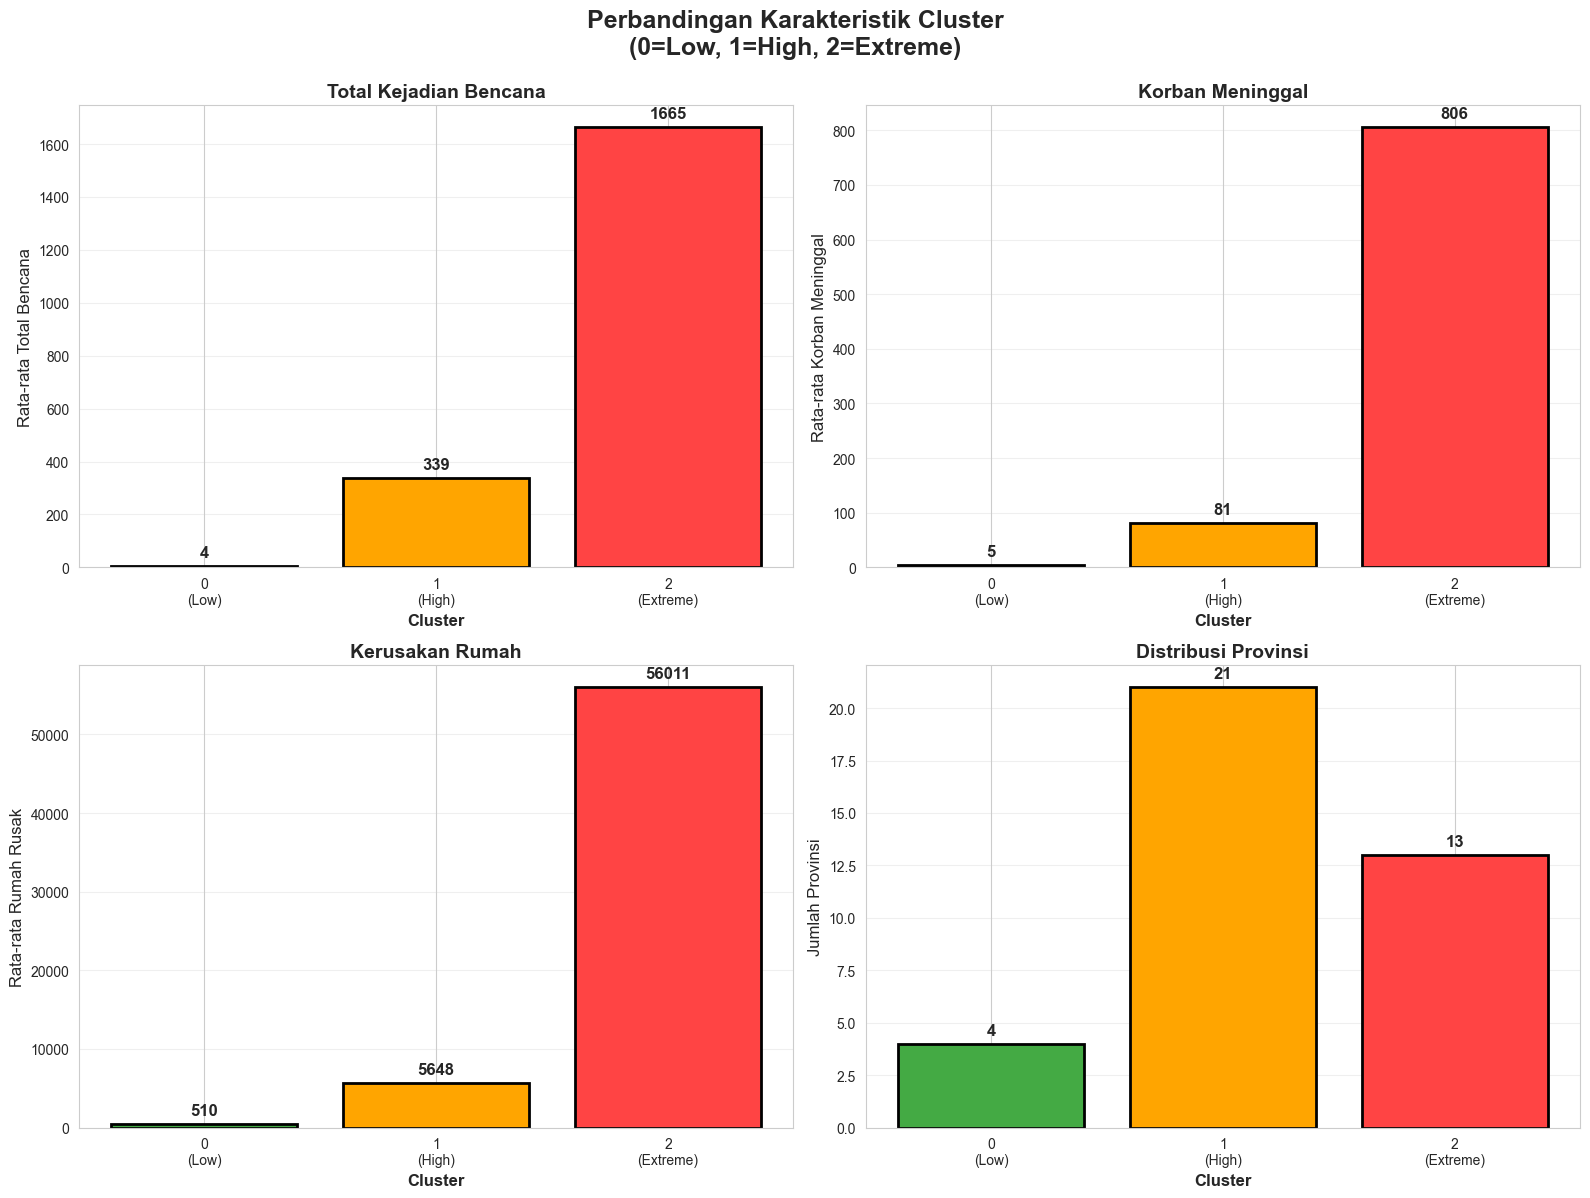

💾 Saved: cluster_comparison.png


In [51]:
# Bar chart comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Perbandingan Karakteristik Cluster\n(' +
             ', '.join(f'{i}={n}' for i, n in enumerate(cluster_labels)) + ')',
             fontsize=18, fontweight='bold', y=0.995)

_palette = ['#44AA44', '#FFA500', '#FF4444', '#8844AA', '#4488FF']
colors_cluster = _palette[:optimal_k]
xticks = list(range(optimal_k))
xticklabels = [f'{i}\n({n})' for i, n in enumerate(cluster_labels)]

def _bar(ax, series, ylabel, title):
    series = series.reindex(range(optimal_k))
    ax.bar(series.index, series.values, color=colors_cluster, edgecolor='black', linewidth=2)
    ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.grid(axis='y', alpha=0.3)
    pad = series.max() * 0.02  # offset label proporsional terhadap tinggi bar
    for i, v in zip(series.index, series.values):
        ax.text(i, v + pad, f'{v:.0f}', ha='center', fontweight='bold', fontsize=12)

# 1. Total Bencana
_bar(axes[0, 0], province_features.groupby('cluster')['total_disasters'].mean(),
     'Rata-rata Total Bencana', 'Total Kejadian Bencana')

# 2. Korban Jiwa
_bar(axes[0, 1], province_features.groupby('cluster')['total_death'].mean(),
     'Rata-rata Korban Meninggal', 'Korban Meninggal')

# 3. Rumah Rusak
_bar(axes[1, 0], province_features.groupby('cluster')['total_damaged_house'].mean(),
     'Rata-rata Rumah Rusak', 'Kerusakan Rumah')

# 4. Jumlah Provinsi
_bar(axes[1, 1], province_features['cluster'].value_counts().sort_index().astype(float),
     'Jumlah Provinsi', 'Distribusi Provinsi')

plt.tight_layout()
plt.savefig('cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: cluster_comparison.png")

## 1️⃣3️⃣ Heatmap Top 15 Provinces

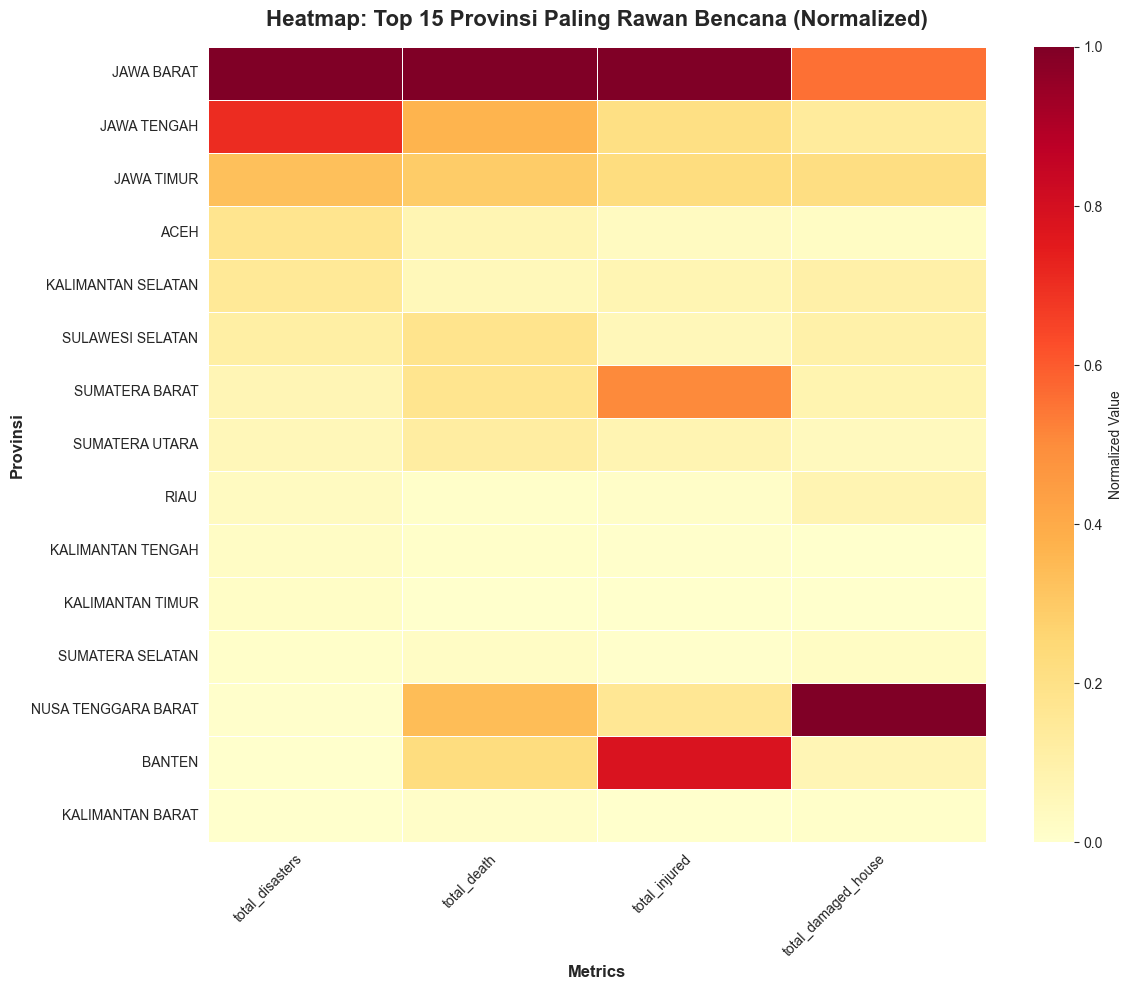

💾 Saved: province_heatmap.png


In [52]:
# Top 15 provinces heatmap
top15 = province_features.nlargest(15, 'total_disasters')[
    ['province', 'cluster', 'total_disasters', 'total_death', 
     'total_injured', 'total_damaged_house']
].copy()

# Normalize
top15_normalized = top15.copy()
for col in ['total_disasters', 'total_death', 'total_injured', 'total_damaged_house']:
    top15_normalized[col] = (top15[col] - top15[col].min()) / (top15[col].max() - top15[col].min())

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(top15_normalized.set_index('province')[
    ['total_disasters', 'total_death', 'total_injured', 'total_damaged_house']
], annot=False, cmap='YlOrRd', cbar_kws={'label': 'Normalized Value'}, 
linewidths=0.5, linecolor='white')

plt.title('Heatmap: Top 15 Provinsi Paling Rawan Bencana (Normalized)', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Provinsi', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('province_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: province_heatmap.png")

## ✅ Summary

### Metodologi (revisi anti-outlier 2018)

- **Merge duplikat provinsi:** `P A P U A`→`PAPUA`, `DAERAH ISTIMEWA YOGYAKARTA`→`DI YOGYAKARTA` → **38 provinsi** (sebelumnya 40).
- **log1p + RobustScaler** menggantikan StandardScaler. log1p meredam ekor kanan ekstrem sehingga satu kejadian katastropik 2018 (Palu/Sulteng, Lombok/NTB, Selat Sunda/Banten) tidak lagi mendominasi clustering. RobustScaler (median & IQR) menahan sisa outlier.
- K optimal ditentukan otomatis via silhouette score (kini **K=2**), dan seluruh visualisasi sudah adaptif terhadap nilai K.

### Hasil Clustering

- **Cluster 0 (Low Risk) — 5 provinsi:** Papua Barat, Papua Barat Daya, Papua Pegunungan, Papua Selatan, Papua Tengah. Provinsi pemekaran 2022 dengan periode data sangat pendek (~1,5 tahun) sehingga jumlah kejadiannya jauh lebih kecil.
- **Cluster 1 (High Risk) — 33 provinsi:** seluruh provinsi lainnya, termasuk Jawa Barat/Tengah/Timur (frekuensi tinggi) dan Sulawesi Tengah (yang sebelumnya menjadi cluster singleton akibat anomali Palu 2018, kini melebur).

> **Catatan:** Anomali singleton Sulteng 2018 sudah teratasi. Namun karena outlier ditekan, faktor pembeda terbesar kini bergeser ke **provinsi pemekaran Papua yang miskin data**. Jika ingin tingkatan risiko yang lebih bermakna (mis. Low/High/Extreme), pertimbangkan menggabungkan provinsi-provinsi Papua baru ke `PAPUA` atau mengecualikannya karena periode datanya tidak setara.

### Output Files

1. `clustering_province_features.csv` - Feature matrix
2. `clustering_results.csv` - Hasil clustering
3. `elbow_method.png` - Grafik penentuan K optimal
4. `clustering_visualization.png` - PCA scatter plot
5. `cluster_comparison.png` - Bar chart comparison
6. `province_heatmap.png` - Heatmap top 15 provinsi

---

🍈 **Project by Guava - Clustering Wilayah Rawan Bencana Indonesia**